In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path = "/Users/liaojiamin/Desktop/DSI/visualization/02_activities/assignments/TTC Subway Delay Data since 2025.csv"
df = pd.read_csv(path) # put data into dataframe

In [2]:
# view the data
print(df.shape)
print(df.columns)
df.head()

(25713, 11)
Index(['_id', 'Date', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap',
       'Bound', 'Line', 'Vehicle'],
      dtype='object')


,_id,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle
0,1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227
1,2,2025-01-01,02:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0
2,3,2025-01-01,02:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0
3,4,2025-01-01,02:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293
4,5,2025-01-01,02:58,Wednesday,COXWELL STATION,SUAE,0,0,NaN,BD,0


In [3]:
# combine date and time
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])

In [4]:
# pull the hours and give day name
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.day_name()

In [5]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# define order of days
counts = (
    df.groupby(["weekday", "hour"]) # group rows by weekday and hour
      .size() # count how many rows in each group --> data for plot
      .unstack(fill_value=0) #fill missing value with 0
      .reindex(weekday_order) # set the correct order of day
)


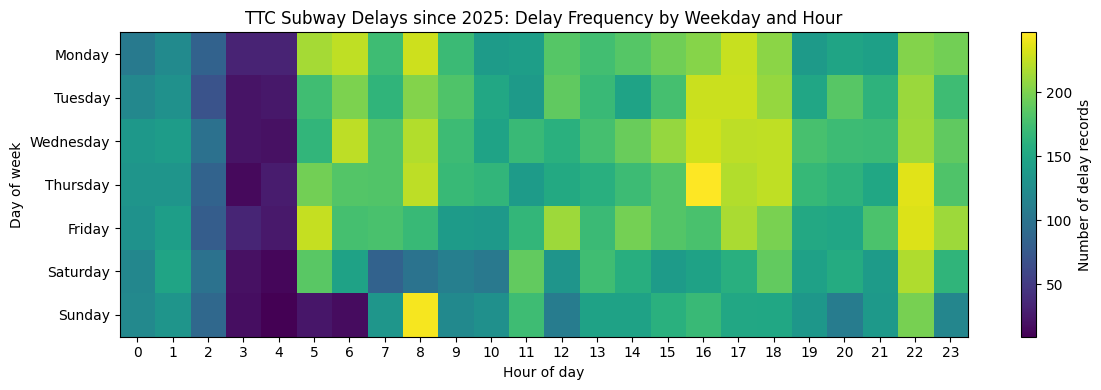

In [6]:
plt.figure(figsize=(12, 4)) # set the size of the figure
plt.imshow(counts.values, aspect="auto") # draws heatmap based on counts
plt.colorbar(label="Number of delay records") # adds legend to show color intensity means

plt.yticks(range(len(counts.index)), counts.index) # label rows with weekday
plt.xticks(range(24), range(24)) # label columns with hours

plt.title("TTC Subway Delays since 2025: Delay Frequency by Weekday and Hour")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
# add the titles

plt.tight_layout()
plt.show()
